Inputs shape: (15, 2)
Outputs shape: (15,)
First 20 rows of raw data:
    number-1  number-2  log-likelyhood-score  source
9   0.702637  0.926564              0.611205    file
13  0.691873  0.263356              0.596081  week-4
0   0.665800  0.123969              0.538996    file
12  0.722766  0.839711              0.533827  week-3
1   0.877791  0.778628              0.420586    file
3   0.845275  0.711120              0.293993    file
6   0.438166  0.685018              0.244619    file
4   0.454647  0.290455              0.214965    file
11  0.616162  1.000000              0.180119  week-2
10  0.818182  0.939394              0.051646  week-1
7   0.341750  0.028698              0.038749    file
5   0.577713  0.771973              0.023106    file
14  0.790304  0.104833              0.016862  week-5
8   0.338648  0.213867             -0.013858    file
2   0.142699  0.349005             -0.065624    file
2025-12-10 23-30-52
Outputs will be written to: results/run_2025-12-10 23-30-52
Cr

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 0.873097, Val Loss: 1.605295
Epoch 50/500, Train Loss: 0.349295, Val Loss: 2.282915
Early stopping at epoch 63, best val_loss=1.504609


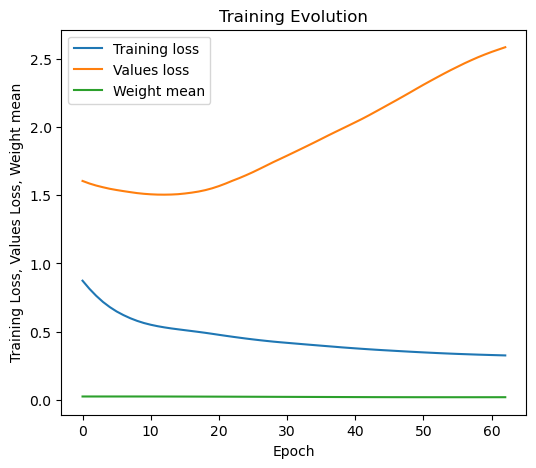

Using 2 dimensions, grid size per axis: 200, downsample: False, stride: 1
Points before downsampling: 40000
Points after downsampling: 40000
Final grid shape: (40000, 2)
Filtered 9658 candidates near decision boundary (|margin| < 0.2)
Excluded 30342 candidates from consideration
Final grid shape after filtering: (9658, 2)
Predictions range (scaled): -1.1886 to 0.4027
Inverse-transforming predictions to raw units
Predictions range (raw): -0.0306 to 0.3393
Total number of points to evaluate: 6
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.04269907, 1.1       ]), 'score': 9.368183833389538e-07, 'dim': 2, 'predicted_y': -0.021525053}
{'method': 'PI', 'xi': 0.5, 'kappa': None, 'x': array([0.04269907, 1.1       ]), 'score': 9.471500877820298e-09, 'dim': 2, 'predicted_y': -0.021525053}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.04269907, 1.1       ]), 'score': 1.0441928079582373e-07, 'dim': 2, 'predicted_y': -0.021525053}
{'method': 'EI', 'xi': 0.5, 'kappa': None, '

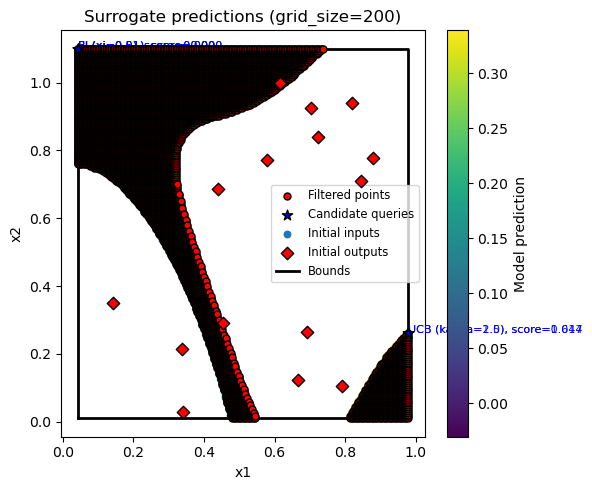

<Figure size 600x500 with 0 Axes>

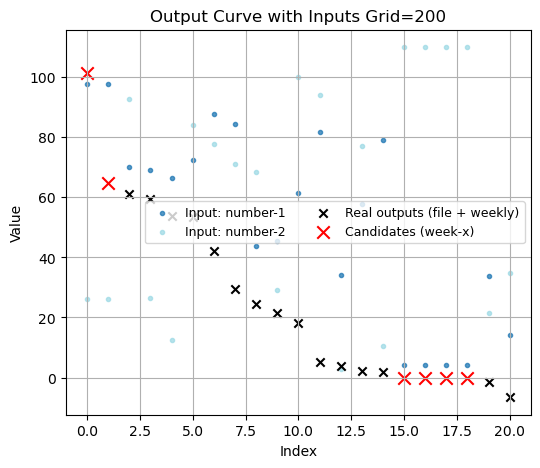

Saved dataframe to: results/run_2025-12-10 23-30-52/df_grid_200_stride1_median_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 2.5, 'x': array([0.97779099, 0.2619598 ]), 'score': 1.0142836427674968, 'dim': 2, 'predicted_y': 0.33928517}
    number-1  number-2  log-likelyhood-score  source  log-likelyhood-score-scaled
0   0.977791  0.261960          1.014284e+00  week-x                 1.000000e+01
1   0.977791  0.261960          6.473498e-01  week-x                 6.382335e+00
2   0.702637  0.926564          6.112052e-01    file                 6.025979e+00
3   0.691873  0.263356          5.960814e-01  week-4                 5.876871e+00
4   0.665800  0.123969          5.389961e-01    file                 5.314057e+00
5   0.722766  0.839711          5.338270e-01  week-3                 5.263094e+00
6   0.877791  0.778628          4.205862e-01    file                 4.146633e+00
7   0.845275  0.711120          2.939929e-01    file                 2.8985

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))